In [8]:
from utils.orientation_map import *
from utils.generation import *
from utils.filters import *
from utils.density_map import *

In [9]:
singularity_type = 3
width = 256
height = 256

core_positions, delta_positions, arch_fact1, arch_fact2, k_arch = (
    init_para_canonical(H=height, W=width, singularity_type=singularity_type)
)
g_cap = set_param_canonical(singularity_type)

o_map = OrientationMap(
    width,
    height,
    singularity_type,
    delta_positions,
    core_positions,
    g_cap,
    arch_fact1,
    arch_fact2,
    k_arch,
)

orientation_map = o_map.getOrientationMap()

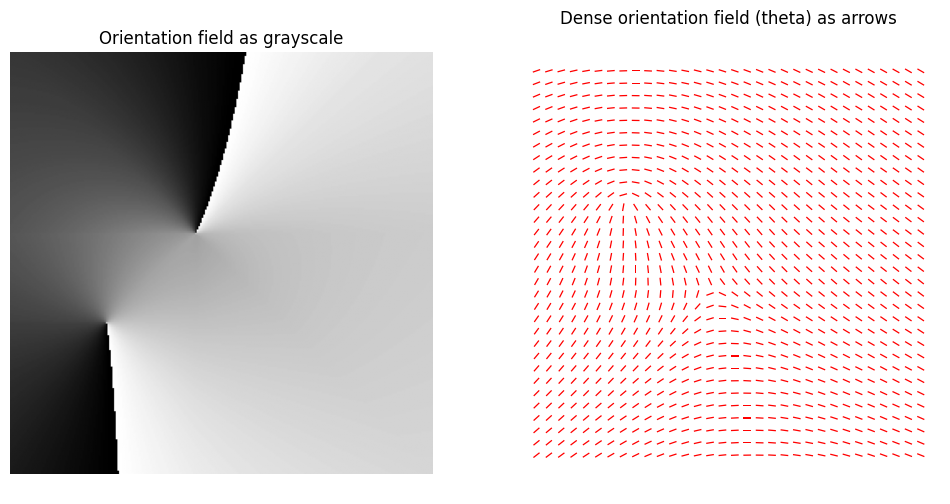

In [10]:
def plot_orientation_field(orientation_map, singularities=[]):
    stride = 8
    ys, xs = np.mgrid[0:height:stride, 0:width:stride]

    U = np.cos(orientation_map[::stride, ::stride])
    V = np.sin(orientation_map[::stride, ::stride])

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(orientation_map, cmap="gray")
    # plt.colorbar()
    plt.title("Orientation field as grayscale")
    plt.axis("off")

    if singularities:
        for (y, x) in singularities:
            plt.plot(x, y, "ro", markersize=10, label="Core")

    plt.subplot(1, 2, 2)
    plt.quiver(
        xs,
        ys,
        U,
        V,
        color="red",
        angles="xy",
        scale_units="xy",
        scale=0.2,
        width=0.003,
        headaxislength=0,
        headlength=0,
        headwidth=0,
        pivot="middle"
    )

    plt.axis("equal")  # Ensures pixels are square
    plt.title("Dense orientation field (theta) as arrows")
    plt.axis("off")

    plt.show()

plot_orientation_field(orientation_map)

[(110, 112), (164, 58)]


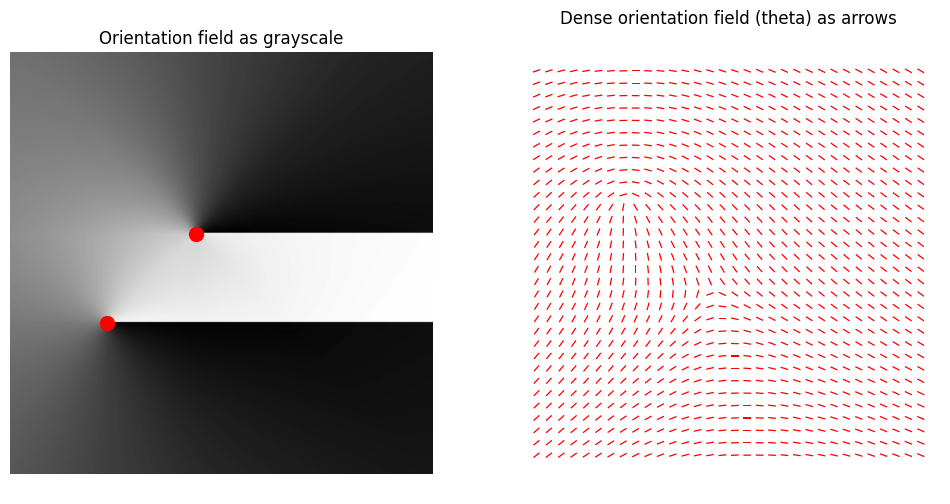

In [11]:
from utils.unwrapping import unwrap_with_smart_cuts, unwrap_with_monotonic_cuts
from utils.unwrap_smooth import unwrap_with_curved_cuts

singularities = []
for item in core_positions + delta_positions:
    c, r = int(item.x), int(item.y)
    if r != 0 and c != 0:
        singularities.append((r, c))

print(singularities)
unwrapped_orientation = None

# if singularities:
#     unwrapped_orientation = unwrap_with_monotonic_cuts(
#         orientation_map,
#         mask=np.ones_like(orientation_map, dtype=bool),
#         singularities=singularities,
#     )
# else:
unwrapped_orientation = unwrap_with_smart_cuts(
    orientation_map,
    mask=np.ones_like(orientation_map, dtype=bool),
    singularities=[],
)

plot_orientation_field(unwrapped_orientation, singularities=singularities)

In [12]:
import numpy as np
from collections import deque

def reconstruct_continuous_phase(unwrapped_orientation, mask, block_size=8, f=0.12):
    # 1. Compute the Gradient Field G (Eq 13) using Complex Exponentials
    # G(m,n) = 2 * pi * f * exp(i * (O_u + pi/2))
    # This replaces manual sin/cos calculations.
    magnitude = 2 * np.pi * f
    # The orientation is shifted by pi/2 to be normal to the ridges
    complex_orientation = np.exp(1j * (unwrapped_orientation + np.pi/2))
    G_complex = magnitude * complex_orientation
    
    # [cite_start]Extract relative real (x) and imaginary (y) components [cite: 18]
    G_cx = np.real(G_complex)
    G_cy = np.imag(G_complex)

    # 2. Initialize Phase Offset P (Eq 14)
    rows, cols = unwrapped_orientation.shape
    P = np.zeros((rows, cols))
    visited = np.zeros((rows, cols), dtype=bool)
    
    # [cite_start]Find start node (first valid foreground block) [cite: 35]
    start_node = None
    for r in range(rows):
        for c in range(cols):
            if mask[r, c]:
                start_node = (r, c)
                break
        if start_node: break
        
    if not start_node:
        return np.zeros((rows * block_size, cols * block_size))

    # BFS Initialization
    queue = deque([start_node])
    visited[start_node] = True
    P[start_node] = 0.0  # Assumption: P(start) = 0 [cite: 35]

    # Directions: (d_row, d_col) -> (top, bottom, left, right)
    neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    print("Starting Block Propagation...")
    
    while queue:
        r, c = queue.popleft()
        
        # [cite_start]Check all 4 connected neighbors [cite: 35]
        for dr, dc in neighbors:
            nr, nc = r + dr, c + dc
            
            # Boundary and Mask Check
            if 0 <= nr < rows and 0 <= nc < cols and mask[nr, nc]:
                if not visited[nr, nc]:
                    # 3. Estimate Phase Offset P for the neighbor (Eq 15)
                    # We compute the offset required to make the phase continuous 
                    # at the shared border pixels.

                    # Determine global pixel coordinates of the shared border
                    # r, c is "Old/Reconstructed", nr, nc is "New/Target"
                    if dr == -1: # Neighbor is Above
                        # Shared border: y = r * block_size
                        border_y = np.full(block_size, r * block_size)
                        border_x = np.arange(c * block_size, (c+1) * block_size)
                    elif dr == 1: # Neighbor is Below
                        # Shared border: y = nr * block_size
                        border_y = np.full(block_size, nr * block_size)
                        border_x = np.arange(c * block_size, (c+1) * block_size)
                    elif dc == -1: # Neighbor is Left
                        # Shared border: x = c * block_size
                        border_x = np.full(block_size, c * block_size)
                        border_y = np.arange(r * block_size, (r+1) * block_size)
                    elif dc == 1: # Neighbor is Right
                        # Shared border: x = nc * block_size
                        border_x = np.full(block_size, nc * block_size)
                        border_y = np.arange(r * block_size, (r+1) * block_size)

                    # Calculate phase projection from the OLD block (already visited)
                    # Psi_old = G_old * pos + P_old
                    psi_from_old = (G_cx[r, c] * border_x + 
                                    G_cy[r, c] * border_y + 
                                    P[r, c])
                    
                    # Calculate gradient projection from the NEW block
                    # Psi_new_grad = G_new * pos
                    psi_from_new_grad = (G_cx[nr, nc] * border_x + 
                                         G_cy[nr, nc] * border_y)
                    
                    # The estimated offset P_new = Psi_old - Psi_new_grad
                    # This ensures Psi_new = Psi_old at the border.
                    estimates = psi_from_old - psi_from_new_grad
                    
                    # [cite_start]4. Complex Averaging of Offsets [cite: 46, 47]
                    # "Phase values cannot be averaged directly... first converted to complex"
                    complex_estimates = np.exp(1j * estimates)
                    complex_mean = np.mean(complex_estimates)
                    
                    # Reconvert to phase (extract angle)
                    P[nr, nc] = np.angle(complex_mean)
                    
                    # Mark visited and enqueue
                    visited[nr, nc] = True
                    queue.append((nr, nc))

    # 4. Construct Final Continuous Phase Image (Eq 14)
    # Psi_C(x,y) = G_cx * x + G_cy * y + P
    
    # Create meshgrids for pixel coordinates
    H_img, W_img = rows * block_size, cols * block_size
    y_grid, x_grid = np.mgrid[0:H_img, 0:W_img]
    
    # Upsample G and P to pixel size (repeat values for each block)
    # Using Kronecker product for efficient block repetition
    G_cx_img = np.kron(G_cx, np.ones((block_size, block_size)))
    G_cy_img = np.kron(G_cy, np.ones((block_size, block_size)))
    P_img = np.kron(P, np.ones((block_size, block_size)))
    
    # Calculate Phase
    continuous_phase = G_cx_img * x_grid + G_cy_img * y_grid + P_img
    
    # Mask out background
    mask_img = np.kron(mask, np.ones((block_size, block_size)))
    continuous_phase[~mask_img.astype(bool)] = 0
    
    return continuous_phase

Starting Block Propagation...


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

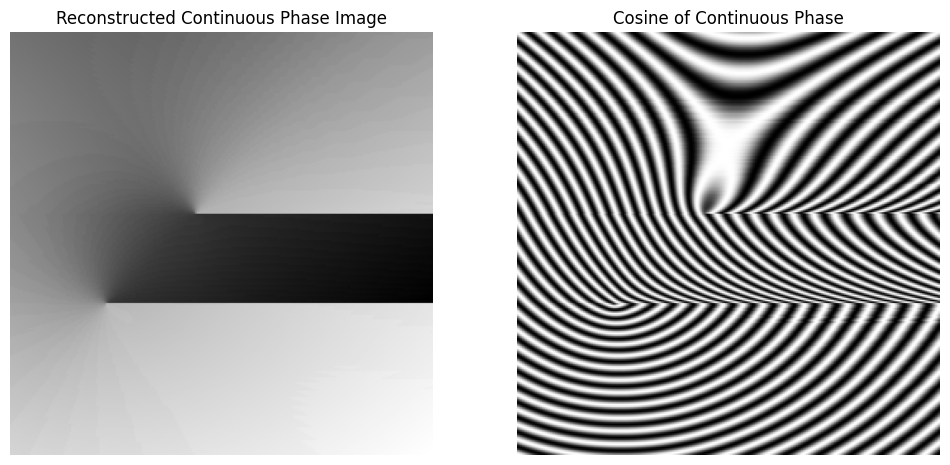

In [13]:
phase = reconstruct_continuous_phase(
    unwrapped_orientation=unwrapped_orientation,
    mask=np.ones_like(unwrapped_orientation, dtype=bool),
    block_size=1,
    f=0.12
)

plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.imshow(phase, cmap="gray")
plt.title("Reconstructed Continuous Phase Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(np.cos(phase), cmap="gray")
plt.title("Cosine of Continuous Phase")
plt.axis("off")

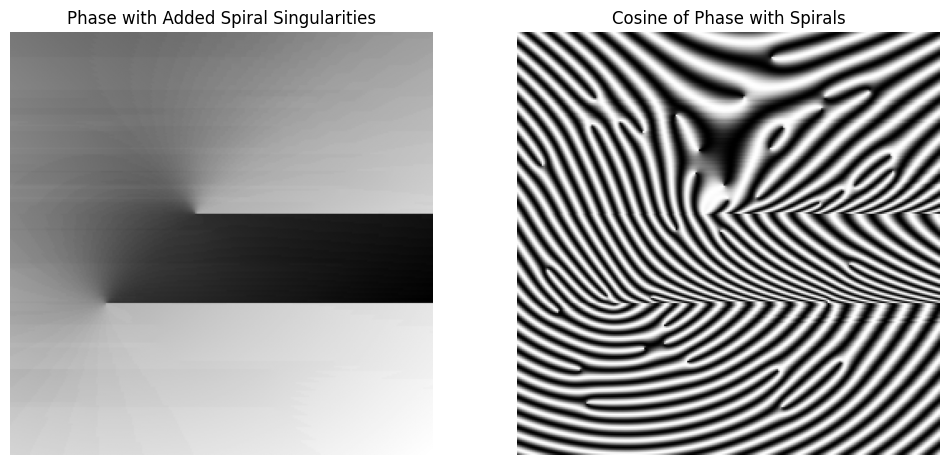

In [14]:
def add_spiral_phase(psi, points, polarities):
    # points: list of (y,x); polarities: +1 for termination, -1 for bifurcation (convention)
    H, W = psi.shape
    Y, X = np.mgrid[:H, :W]
    out = psi.copy()
    zero = np.zeros_like(psi)
    for (yy, xx), p in zip(points, polarities):
        zero += p * np.arctan2(Y - yy, X - xx)

    out += zero
    return out


spiral_phase_coords = []
spiral_phase_polarities = []

for _ in range(40):
    y = random.randint(12, 230)
    x = random.randint(12, 230)
    spiral_phase_coords.append((y, x))

    polarity = random.choice([1, -1])
    spiral_phase_polarities.append(polarity)

phase_with_spirals = add_spiral_phase(phase, spiral_phase_coords, spiral_phase_polarities)
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.imshow(phase_with_spirals, cmap="gray")
plt.title("Phase with Added Spiral Singularities")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(np.cos(phase_with_spirals), cmap="gray")
plt.title("Cosine of Phase with Spirals")
plt.axis("off")
plt.show()